# CT-SeqTrack v24 B0 / B1-only 诊断

本 notebook 只读取本地 `output/` 与 Git 对象，不修改训练结果。核心问题：当前 B0 是否大幅衰退；B1 是否真正学到了优于恒速外推的均值与可信不确定度；下一步应优先修复什么。

## TL;DR

- 当前 B0 已完成 60 epoch，但记录的是 mini_train 的 37-tracklet dev 分区，不是独立 mini_val。
- 与历史 CT22 同类 dev 曲线相比，当前 B0 的 epoch60 与 late-3 均出现约 5–9 个点的下降，是强回退预警。
- B1-only 本地副本只到 epoch52、正式验证到 epoch50；它的均值外推没有优于 CV，NLL 恶化且 95% 覆盖率远低于 95%。
- 更靠前的阻塞是：B0 与 B1-only 从第 2 个训练 step 起，B0 loss 轨迹就分叉，违反预期的 B0/B1 隔离。先修复 B0 非回退与隔离，再修 B1 均值/不确定度，最后才加入新创新点。

In [1]:
from pathlib import Path
import json, subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

def find_repo(start=Path.cwd()):
    for candidate in (start, *start.parents):
        if (candidate / '.git').exists() and (candidate / 'models').exists():
            return candidate
    raise RuntimeError('CT-SeqTrack repository root not found')

ROOT = find_repo()
B0_RUN = ROOT / 'output/20260822-0330-24_b0-ct24_b0_car_seed42_60ep_bs16_'
B1_RUN = ROOT / 'output/20260822-0330-24_b1-ct24_b1_only_car_seed42_60ep_bs16_'
B0_LOG = B0_RUN / 'lightning_logs/version_0'
B1_LOG = B1_RUN / 'lightning_logs/version_0'
assert B0_LOG.exists() and B1_LOG.exists()

def scalar_series(log_dir, folder):
    ea = EventAccumulator(str(log_dir / folder), size_guidance={'scalars': 0})
    ea.Reload()
    tags = ea.Tags()['scalars']
    if len(tags) != 1:
        raise RuntimeError(f'{folder}: expected one scalar tag, got {tags}')
    return pd.DataFrame([(x.step, x.value) for x in ea.Scalars(tags[0])], columns=['step', 'value'])

def validation_curve(log_dir):
    success = scalar_series(log_dir, 'metrics_test_success').rename(columns={'value': 'success'})
    precision = scalar_series(log_dir, 'metrics_test_precision').rename(columns={'value': 'precision'})
    curve = success.merge(precision, on='step', validate='one_to_one')
    steps_per_epoch = int(round(curve.iloc[0].step / 5))
    curve['epoch'] = (curve.step / steps_per_epoch).round().astype(int)
    return curve[['epoch', 'step', 'success', 'precision']], steps_per_epoch

b0_prov = json.loads((B0_RUN / 'run_provenance.json').read_text(encoding='utf-8'))
b1_prov = json.loads((B1_RUN / 'run_provenance.json').read_text(encoding='utf-8'))
b0_curve, b0_spe = validation_curve(B0_LOG)
b1_curve, b1_spe = validation_curve(B1_LOG)
assert b0_prov['git']['commit'] == b1_prov['git']['commit']
assert b0_prov['seed'] == b1_prov['seed'] == 42
assert not b0_prov['git']['dirty_any'] and not b1_prov['git']['dirty_any']
assert b0_prov['init_checkpoint_path'] is None and b1_prov['init_checkpoint_path'] is None
run_quality = pd.DataFrame([
    {'run': 'B0', 'commit': b0_prov['git']['commit'][:8], 'seed': b0_prov['seed'], 'steps_per_epoch': b0_spe, 'validation_points': len(b0_curve), 'last_validation_epoch': b0_curve.epoch.max(), 'acquisition_epochs': len(list((B0_LOG / 'acquisition_supply').glob('epoch_*.json')))},
    {'run': 'B1-only', 'commit': b1_prov['git']['commit'][:8], 'seed': b1_prov['seed'], 'steps_per_epoch': b1_spe, 'validation_points': len(b1_curve), 'last_validation_epoch': b1_curve.epoch.max(), 'acquisition_epochs': len(list((B1_LOG / 'acquisition_supply').glob('epoch_*.json')))},
])
display(run_quality)
b0_curve, b1_curve

,run,commit,seed,steps_per_epoch,validation_points,last_validation_epoch,acquisition_epochs
0,B0,a00935a1,42,213,12,60,60
1,B1-only,a00935a1,42,213,10,50,52


(    epoch   step    success  precision
 0       5   1065  25.359741  36.475288
 1      10   2130  20.875727  28.473837
 2      15   3195  22.547239  35.915695
 3      20   4260  22.852472  30.421507
 4      25   5325  40.330669  53.321224
 5      30   6390  40.090847  51.831394
 6      35   7455  39.763809  51.402618
 7      40   8520  28.637356  39.858280
 8      45   9585  43.244915  52.082123
 9      50  10650  42.292873  51.718754
 10     55  11715  42.779797  53.135902
 11     60  12780  41.079212  49.916424,
    epoch   step    success  precision
 0      5   1065  21.638809  33.241280
 1     10   2130  30.112644  44.258724
 2     15   3195  18.695494  23.880814
 3     20   4260  31.871367  41.351742
 4     25   5325  39.109737  49.607555
 5     30   6390  42.380085  51.337208
 6     35   7455  37.089382  43.273983
 7     40   8520  28.179506  35.846657
 8     45   9585  43.288521  47.772530
 9     50  10650  39.422241  41.813229)

## 数据完整性与可比性

当前 B0 与 B1-only 都是 seed42、scratch、同一 commit、同一 37-tracklet dev 验证分区。B0 有 12 个验证点并完成 60 epoch；B1 本地副本只有 10 个验证点（至 epoch50）以及 52 个 acquisition epoch 文件。因此 B1 结论是进度诊断，不是最终 60-epoch结论。历史 CT22 dev 曲线是最接近的参考，但当前输出未包含可逐 tracklet 核验的分区清单，比较属于强方向证据而非正式配对证明。

,metric,v24,ct22,delta_v24_minus_ct22
0,Success epoch60,41.079,49.800,-8.721
1,Precision epoch60,49.916,57.773,-7.856
2,Success late-3,42.051,47.523,-5.472
3,Precision late-3,51.590,56.955,-5.365


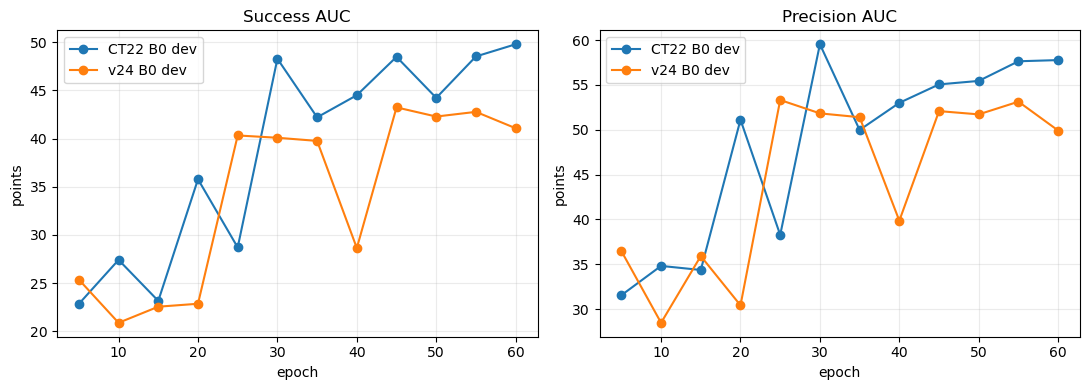

In [2]:
def git_json(spec):
    raw = subprocess.check_output(['git', 'show', spec], cwd=ROOT)
    return json.loads(raw.decode('utf-8'))

ct22 = git_json('001951a:compare_results/data/ct22_b0_diagnosis_20260811.json')
ct22_curve = pd.DataFrame(ct22['dev_curves'])[['epoch', 'success', 'precision']]
ct22_curve['run'] = 'CT22 B0 dev'
current = b0_curve[['epoch', 'success', 'precision']].copy()
current['run'] = 'v24 B0 dev'

def late3(frame, column):
    return frame.tail(3)[column].mean()

b0_compare = pd.DataFrame([
    {'metric': 'Success epoch60', 'v24': current.iloc[-1].success, 'ct22': ct22_curve.iloc[-1].success},
    {'metric': 'Precision epoch60', 'v24': current.iloc[-1].precision, 'ct22': ct22_curve.iloc[-1].precision},
    {'metric': 'Success late-3', 'v24': late3(current, 'success'), 'ct22': late3(ct22_curve, 'success')},
    {'metric': 'Precision late-3', 'v24': late3(current, 'precision'), 'ct22': late3(ct22_curve, 'precision')},
])
b0_compare['delta_v24_minus_ct22'] = b0_compare.v24 - b0_compare.ct22
display(b0_compare.round(3))

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharex=True)
for frame, label in [(ct22_curve, 'CT22 B0 dev'), (current, 'v24 B0 dev')]:
    axes[0].plot(frame.epoch, frame.success, marker='o', label=label)
    axes[1].plot(frame.epoch, frame.precision, marker='o', label=label)
axes[0].set(title='Success AUC', xlabel='epoch', ylabel='points')
axes[1].set(title='Precision AUC', xlabel='epoch', ylabel='points')
for ax in axes: ax.grid(alpha=.25); ax.legend()
plt.tight_layout(); plt.show()

## B1 均值与不确定度

候选诊断只统计能形成 proposal 诊断的行；它与官方全帧 tracking 指标的总体不同。这里仅用于判断 B1 prior 的均值和不确定度质量。`b1_valid=1` 行上比较 learned motion 与 kinematic CV；coverage 是模型椭圆对真实误差的经验覆盖率。

,epoch,proposal_rows,b1_valid_rows,learned_rmse,cv_rmse,learned_mean_error,learned_median_error,nll,sigma_parallel,sigma_perpendicular,coverage_50,coverage_80,coverage_95,mahalanobis_mean
0,5,556,525,17.322,17.323,7.243,1.174,689.683,0.565,0.382,0.217,0.370,0.476,1382.524
1,10,545,514,16.587,16.579,6.400,0.865,794.571,0.467,0.366,0.325,0.465,0.636,1592.738
2,15,534,503,17.065,17.069,7.262,0.843,803.322,0.565,0.387,0.429,0.481,0.553,1609.833
3,20,536,505,19.270,19.262,7.830,0.590,1287.060,0.516,0.383,0.448,0.602,0.644,2577.602
4,25,549,518,16.736,16.732,6.888,0.475,1978.871,0.388,0.353,0.463,0.585,0.639,3961.861
5,30,530,499,19.092,19.090,7.635,0.533,1700.474,0.408,0.359,0.453,0.575,0.617,3404.921
6,35,530,499,18.864,18.860,7.680,0.833,1617.097,0.468,0.370,0.381,0.467,0.553,3237.863
7,40,528,497,18.885,18.876,7.448,0.616,1528.443,0.433,0.360,0.451,0.537,0.604,3060.754
8,45,530,499,19.263,19.260,7.765,0.797,1759.732,0.432,0.364,0.415,0.489,0.557,3523.338
9,50,514,483,21.315,21.305,9.647,0.889,2444.300,0.430,0.360,0.360,0.435,0.520,4892.529


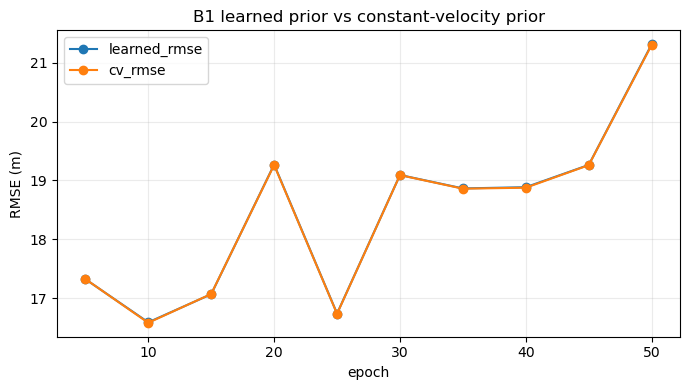

{'nll_growth_x_epoch5_to_50': 3.5440897146868506, 'learned_minus_cv_rmse_m_epoch50': 0.010531488474867956, 'coverage95_gap_percentage_points_epoch50': -43.03312629399586}


In [3]:
rows = []
for csv_path in sorted((B1_LOG / 'candidate_diagnostics').glob('epoch_*.csv')):
    epoch = int(csv_path.stem.split('_')[-1])
    df = pd.read_csv(csv_path)
    valid = df[df.b1_valid == 1].copy()
    rows.append({
        'epoch': epoch, 'proposal_rows': len(df), 'b1_valid_rows': len(valid),
        'learned_rmse': np.sqrt(np.mean(valid.learned_motion_error ** 2)),
        'cv_rmse': np.sqrt(np.mean(valid.kinematic_error ** 2)),
        'learned_mean_error': valid.learned_motion_error.mean(),
        'learned_median_error': valid.learned_motion_error.median(),
        'nll': valid.b1_nll.mean(),
        'sigma_parallel': valid.sigma_parallel.mean(),
        'sigma_perpendicular': valid.sigma_perpendicular.mean(),
        'coverage_50': valid.b1_coverage_50.mean(),
        'coverage_80': valid.b1_coverage_80.mean(),
        'coverage_95': valid.b1_coverage_95.mean(),
        'mahalanobis_mean': valid.b1_mahalanobis_sq.mean(),
    })
b1_diag = pd.DataFrame(rows).sort_values('epoch')
display(b1_diag.round(3))

ax = b1_diag.plot(x='epoch', y=['learned_rmse', 'cv_rmse'], marker='o', figsize=(7, 4))
ax.set(title='B1 learned prior vs constant-velocity prior', ylabel='RMSE (m)', xlabel='epoch')
ax.grid(alpha=.25); plt.tight_layout(); plt.show()

last = b1_diag.iloc[-1]
print({
    'nll_growth_x_epoch5_to_50': last.nll / b1_diag.iloc[0].nll,
    'learned_minus_cv_rmse_m_epoch50': last.learned_rmse - last.cv_rmse,
    'coverage95_gap_percentage_points_epoch50': 100 * (last.coverage_95 - 0.95),
})

## B0/B1 隔离检查

若 B1 的 detach、独立 optimizer 与 observation-only 递归提交完全成立，至少在相同 seed/数据顺序的可比开局中，B0 loss 不应在第一次事务后立即大幅分叉。这里比较两个 run 的同 step `loss_b0_candidate0` 和 `loss_b0_auxiliary`。它不能单独定位根因，但能定位最早出现差异的时点。

In [4]:
loss_checks = []
for folder in ['loss_loss_b0_candidate0', 'loss_loss_b0_auxiliary']:
    left = scalar_series(B0_LOG, folder).rename(columns={'value': 'b0'})
    right = scalar_series(B1_LOG, folder).rename(columns={'value': 'b1'})
    aligned = left.merge(right, on='step', validate='one_to_one')
    aligned['abs_diff'] = (aligned.b0 - aligned.b1).abs()
    first_diff = aligned.loc[aligned.abs_diff > 0].iloc[0]
    loss_checks.append({
        'loss': folder.replace('loss_loss_', ''),
        'aligned_steps': len(aligned),
        'first_different_step': int(first_diff.step),
        'b0_at_first_difference': first_diff.b0,
        'b1_at_first_difference': first_diff.b1,
        'mean_abs_difference': aligned.abs_diff.mean(),
        'max_abs_difference': aligned.abs_diff.max(),
        'exactly_equal_steps': int((aligned.abs_diff == 0).sum()),
    })
display(pd.DataFrame(loss_checks).round(6))

aligned_tracking = b0_curve.merge(b1_curve, on='epoch', suffixes=('_b0', '_b1'))
aligned_tracking['delta_success_b1_minus_b0'] = aligned_tracking.success_b1 - aligned_tracking.success_b0
aligned_tracking['delta_precision_b1_minus_b0'] = aligned_tracking.precision_b1 - aligned_tracking.precision_b0
display(aligned_tracking[['epoch', 'delta_success_b1_minus_b0', 'delta_precision_b1_minus_b0']].round(3))

,loss,aligned_steps,first_different_step,b0_at_first_difference,b1_at_first_difference,mean_abs_difference,max_abs_difference,exactly_equal_steps
0,b0_candidate0,11156,1,33.246838,38.719875,0.845095,9.483208,1
1,b0_auxiliary,11156,5,21.585674,21.585892,0.370684,4.256081,5


,epoch,delta_success_b1_minus_b0,delta_precision_b1_minus_b0
0,5,-3.721,-3.234
1,10,9.237,15.785
2,15,-3.852,-12.035
3,20,9.019,10.930
4,25,-1.221,-3.714
5,30,2.289,-0.494
6,35,-2.674,-8.129
7,40,-0.458,-4.012
8,45,0.044,-4.310
9,50,-2.871,-9.906


## 结论与下一步

1. 目前不能接受“基线没有大幅衰退”这个前提。v24 B0 相对 CT22 同类 dev 参考的 epoch60 下降约 8.7 Success / 7.9 Precision，late-3 下降约 5.5 / 5.4；即使缺少逐 tracklet 配对清单，这也已经是需要先处理的强回退信号。
2. 不应现在把新创新点同时融入各模块。否则基线回退、隔离泄漏、B1 失效与新模块作用会互相混淆，论文无法做可信归因。
3. 优先级 P0：用 B0 last checkpoint 做独立 mini_val 评测；补齐 B1 epoch60；做固定真实 batch 的两步 B0-vs-B1 输入、B0 输出、BN buffer、B0 grad、optimizer moment、递归提交与 RNG hash 检查，定位第一次分叉；核对 213 steps/epoch 带来的优化预算变化。
4. P0 通过后，P1 才是修复 B1。当前问题不只是‘sigma 塌到 0’，而是 learned mean 与 CV 基本持平/略差、NLL 变坏、长尾极重、经验覆盖严重不足。应把均值优于 CV 与不确定度校准作为一个完整 B1 修复任务。
5. 只有 B0 非回退、B0/B1 隔离成立、B1 在部署型递归历史上稳定优于 CV 后，再一次只加入一个新创新点，并运行 scratch 消融。